# Replication - Figures, Statistical Analyses, Metacognitive Sensitivty

This notebook contains the figures, statistical analyses, and the metacognitive efficiency estimations applicable to Experiment 3. In Rouault et al. (2019), this experiment serves to provide direct evidence that changes in local confidence were predictive of global SPEs, as well as replicate the findings from Experiments 1 and 2. Here, N = 46, whereas the prior two used N = 29 each.

The selected figures are:
1. Confidence level relative to accuracy and task difficulty
2. Logistic Regression, with accuracy, confidence, and reaction times as regressors
3. Task choice relative to differences in local confidence between tasks (large, small)
4. Metacognitive efficiency, relative to task difficulty

Main statistical analyses include :
- Paired within-subject t-tests - task performance comparison (per difficulty, feedback/confidence manipulation) + confidence ratings (difficulty, accuracy)
- Logistic regression (accuracy, confidence, reaction time), measuring effect of block duration on task choice
- Logistic regression (accuracy, confidence, reaction time), predicting end-of-block task choice
- BIC model comparison

Metacognitive efficiency represents the efficacy with which confidence ratings discriminate between correct and incorrect judgements (Maniscalo, 2020). It is quantified by meta-d', an SDT-based measure that analyses the corresponde between accuracy and confidence. This is then compared (through substraction or ratio) to the primary task performance - d' - to measure its influence on metacognitive sensitivity. This method was extended to be estimated hierarchically (Fleming, 2017).
Maniscarlo & Lau, 2012 : http://www.columbia.edu/~bsm2105/type2sdt/
Fleming, 2017 : https://github.com/metacoglab/HMeta-d

In [54]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
import matplotlib.pyplot as plt

In [55]:
# Load objects + variables from original MATLAB file

notebook_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
project_root = notebook_dir.parent
data_file = project_root / "data" / "Exp3.mat"

if not data_file.exists():
    raise FileNotFoundError(f"Could not find Exp3.mat at {data_file}. Please ensure the data file is in the correct location.")

mat = sio.loadmat(str(data_file), squeeze_me=True, struct_as_record=False)
Exp3 = mat["Exp3"]

T = Exp3.T
T1chperser = Exp3.T1chperser
T2chperser = Exp3.T2chperser
T1chperserH = Exp3.T1chperserH
T2chperserH = Exp3.T2chperserH
T1chperserL = Exp3.T1chperserL
T2chperserL = Exp3.T2chperserL
acct1perser = Exp3.acct1perser
acct2perser = Exp3.acct2perser
RTt1perser = Exp3.RTt1perser 
RTt2perser = Exp3.RTt2perser
L_H1_H2 = Exp3.L_H1_H2
RT_H1_H2 = Exp3.RT_H1_H2
task1val = Exp3.task1val
task2val = Exp3.task2val
P = Exp3.P
evol_indiv_RT_LB = Exp3.evol_indiv_RT_LB
task_ch_fbeasy = Exp3.task_ch_fbeasy
task_ch_fbdif = Exp3.task_ch_fbdif
task_ch_nofbeasy = Exp3.task_ch_nofbeasy
task_ch_nofbdif = Exp3.task_ch_nofbdif
confidence_level_pooled = Exp3.confidence_level_pooled
mratios = Exp3.mratios
confCorrIncorr = Exp3.confCorrIncorr
conf_perf_correlation = Exp3.conf_perf_correlation
regLB_all = Exp3.regLB_all
X_ser6_all = Exp3.X_ser6_all
nR_S1_E = Exp3.nR_S1_E
nR_S2_E = Exp3.nR_S2_E
nR_S1_D = Exp3.nR_S1_D
nR_S2_D = Exp3.nR_S2_D
auroc2 = Exp3.auroc2

In [56]:
# Plot constants

x2, x3, x4, x5, x6, x8, x12, x30 = (
    np.arange(1, 3),
    np.arange(1, 4),
    np.arange(1, 5),
    np.arange(1, 6),
    np.arange(1, 7),
    np.arange(1, 9),
    np.arange(1, 13),
    np.arange(1, 31),
)

sss = 0.27 # plot offsets
ttt = 0.17 # plot offsets

colorE = np.array([0, 153, 51]) / 255
colorD = np.array([255, 153, 21]) / 255
color_grey = np.array([0.2, 0.2, 0.2])

nS = T.shape[0]
print(nS)

46


In [57]:
# Statistical Analyses


# T-stat : performance-confidence relationship
print("1. Performance-Confidence Relationship")
conf_correct = np.nanmean(confCorrIncorr[:, [0, 2]], axis=1)
conf_incorrect = np.nanmean(confCorrIncorr[:, [1, 3]], axis=1)
t_stat_corr, p_val_corr = stats.ttest_rel(
    conf_correct,
    conf_incorrect
)
print(f"Mean confidence (correct): {np.nanmean(conf_correct):.4f} ± {stats.sem(conf_correct, nan_policy='omit'):.4f}")
print(f"Mean confidence (incorrect): {np.nanmean(conf_incorrect):.4f} ± {stats.sem(conf_incorrect, nan_policy='omit'):.4f}")
print(f"Paired t-test: t = {t_stat_corr:.4f}, p = {p_val_corr:.6g}")
if p_val_corr < 0.001:
    print("*** Highly significant (p < 0.001)")
elif p_val_corr < 0.01:
    print("** Significant (p < 0.01)")
elif p_val_corr < 0.05:
    print("* Significant (p < 0.05)")
    print(confCorrIncorr.shape)
print()


# T-stat : difficulty-confidence relationship
print("2. Difficulty-Confidence Relationship")
conf_easy = confidence_level_pooled[:, 0] 
conf_diff = confidence_level_pooled[:, 1]
t_stat_conf, p_val_conf = stats.ttest_rel(conf_easy, conf_diff)
print(f"Mean confidence (Easy): {np.mean(conf_easy):.4f} ± {np.std(conf_easy)/np.sqrt(nS):.4f}")
print(f"Mean confidence (Difficult): {np.mean(conf_diff):.4f} ± {np.std(conf_diff)/np.sqrt(nS):.4f}")
print(f"Paired t-test: t = {t_stat_conf:.4f}, p = {p_val_conf:.6f}")
if p_val_conf < 0.001:
    print("*** Highly significant (p < 0.001)")
elif p_val_conf < 0.01:
    print("** Significant (p < 0.01)")
elif p_val_conf < 0.05:
    print("* Significant (p < 0.05)")
    print(confCorrIncorr.shape)
print()


# ANOVA : task choice by difficulty × feedback
print("3. Two-way Repeated-measures ANOVA: task choice by difficulty × feedback")
fb_easy = np.nanmean(task_ch_fbeasy, axis=1)
fb_diff = np.nanmean(task_ch_fbdif, axis=1)
nofb_easy = np.nanmean(task_ch_nofbeasy, axis=1)
nofb_diff = np.nanmean(task_ch_nofbdif, axis=1)

df_wide = pd.DataFrame({
    "subject": np.arange(len(fb_easy)),
    "FB_Easy": fb_easy,
    "FB_Diff": fb_diff,
    "NoFB_Easy": nofb_easy,
    "NoFB_Diff": nofb_diff,
})
df_long = df_wide.melt(
    id_vars="subject",
    var_name="condition",
    value_name="choice"
)
df_long[["feedback", "difficulty"]] = df_long["condition"].str.split("_", expand=True)
df_long["choice_transformed"] = 2 * np.arcsin(
    np.sqrt(np.clip(df_long["choice"], 0, 1))
)
anova = AnovaRM(
    data=df_long,
    depvar="choice_transformed",
    subject="subject",
    within=["feedback", "difficulty"]
).fit()
print(anova)


# Logistic Regression : task choice in no-feedback condition (pairing 6)
print("4. Logistic Regression : Task choice in no-feedback condition (pairing 6)")

## Full model: with confidence
Xacc = X_ser6_all[:, 3]
Xrt = X_ser6_all[:, 4]
Xconf = X_ser6_all[:, 5]
print("\nFull Model: Xacc + Xrt + Xconf (z-scored)")
Xacc_z = (Xacc - np.mean(Xacc)) / np.std(Xacc)
Xrt_z = (Xrt - np.mean(Xrt)) / np.std(Xrt)
Xconf_z = (Xconf - np.mean(Xconf)) / np.std(Xconf)
X_full = np.column_stack([Xacc_z, Xrt_z, Xconf_z])
Y_choice = np.array(X_ser6_all[:, 6], dtype=int) - 1  # Convert to 0/1 for task choice
logit_full = sm.GLM(Y_choice, sm.add_constant(X_full), family=sm.families.Binomial()).fit(disp=0)
print(logit_full.summary())

## BIC for full model
llh_full = logit_full.llf
bic_full = -2 * llh_full + (3 + 1) * np.log(len(Y_choice))  # 3 regressors + constant
print(f"\nLog-likelihood (full): {llh_full:.4f}")
print(f"BIC (full model): {bic_full:.4f}")
print()

## Reduced model: without confidence
print("Reduced Model: Xacc + Xrt (z-scored, no confidence)")
X_reduced = np.column_stack([Xacc_z, Xrt_z])
logit_reduced = sm.GLM(Y_choice, sm.add_constant(X_reduced), family=sm.families.Binomial()).fit(disp=0)
print(logit_reduced.summary())

## BIC for reduced model
llh_reduced = logit_reduced.llf
bic_reduced = -2 * llh_reduced + (2 + 1) * np.log(len(Y_choice))  # 2 regressors + constant
print(f"\nLog-likelihood (reduced): {llh_reduced:.4f}")
print(f"BIC (reduced model): {bic_reduced:.4f}")
print()

## Model comparison
print("Model Comparison (BIC)")
print(f"ΔBIC (reduced - full) = {bic_reduced - bic_full:.4f}")
if bic_reduced - bic_full > 10:
    print("Strong evidence for full model (with confidence)")
elif bic_reduced - bic_full > 6:
    print("Moderate evidence for full model")
elif bic_reduced - bic_full > 2:
    print("Weak evidence for full model")
else:
    print("Model comparison ambiguous")
print()

# Metacognitive Efficiency vs Task Choice Difference (using precomputed values for this analysis)
print("5. Metacognitive Efficiency vs Task Choice Difference")
delta_task_ch = T2chperser[:, 5] - T1chperser[:, 5]
MratioAvg = (mratios[:, 0] + mratios[:, 1]) / 2
AUROCMAvg = (auroc2[:, 0] + auroc2[:, 1]) / 2

## MLE M-ratio — all N=46 (negative M-ratios included; excluding them removes structural variance)
r_m, p_m = stats.pearsonr(delta_task_ch, MratioAvg)
rho_m, p_rho_m = stats.spearmanr(delta_task_ch, MratioAvg)
print(f"\nMLE M-ratio:")
print(f"Pearson: r = {r_m:.4f}, p = {p_m:.6f}")
print(f"Spearman: ρ = {rho_m:.4f}, p = {p_rho_m:.6f}")

# AUROC2
r_a, p_a = stats.pearsonr(delta_task_ch, AUROCMAvg)
rho_a, p_rho_a = stats.spearmanr(delta_task_ch, AUROCMAvg)
print(f"\nAUROC2:")
print(f"Pearson:  r = {r_a:.4f}, p = {p_a:.6f}")
print(f"Spearman: ρ = {rho_a:.4f}, p = {p_rho_a:.6f}")

1. Performance-Confidence Relationship
Mean confidence (correct): 0.7994 ± 0.0144
Mean confidence (incorrect): 0.7189 ± 0.0148
Paired t-test: t = 10.0453, p = 4.51243e-13
*** Highly significant (p < 0.001)

2. Difficulty-Confidence Relationship
Mean confidence (Easy): 0.8176 ± 0.0151
Mean confidence (Difficult): 0.7565 ± 0.0140
Paired t-test: t = 8.8954, p = 0.000000
*** Highly significant (p < 0.001)

3. Two-way Repeated-measures ANOVA: task choice by difficulty × feedback
                      Anova
                    F Value Num DF  Den DF Pr > F
-------------------------------------------------
feedback            76.8501 1.0000 45.0000 0.0000
difficulty          87.6082 1.0000 45.0000 0.0000
feedback:difficulty  4.7739 1.0000 45.0000 0.0341

4. Logistic Regression : Task choice in no-feedback condition (pairing 6)

Full Model: Xacc + Xrt + Xconf (z-scored)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Ob

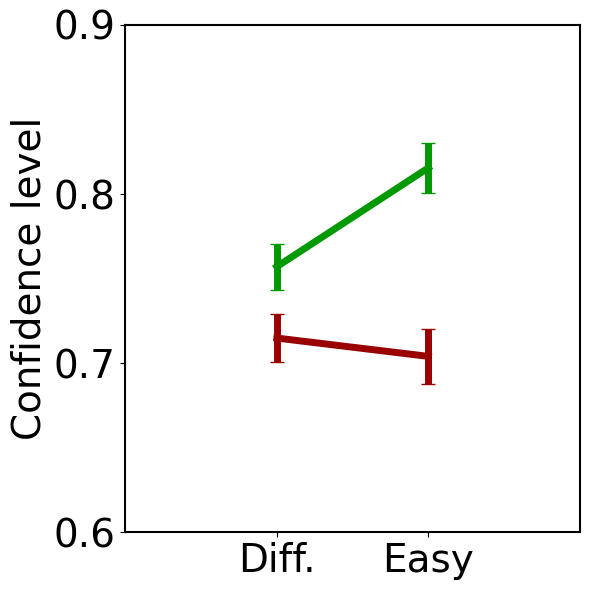

In [58]:
# Figure 5A: Mean confidence by accuracy (correct/incorrect) and difficulty (easy/difficult)
confCorrIncorrPlot = confCorrIncorr[~np.isnan(confCorrIncorr).any(axis=1)]

mean_corr   = [confCorrIncorrPlot[:, 2].mean(), confCorrIncorrPlot[:, 0].mean()]
sem_corr    = [confCorrIncorrPlot[:, 2].std(ddof=1) / np.sqrt(nS),
               confCorrIncorrPlot[:, 0].std(ddof=1) / np.sqrt(nS)]
mean_incorr = [confCorrIncorrPlot[:, 3].mean(), confCorrIncorrPlot[:, 1].mean()]
sem_incorr  = [confCorrIncorrPlot[:, 3].std(ddof=1) / np.sqrt(nS),
               confCorrIncorrPlot[:, 1].std(ddof=1) / np.sqrt(nS)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar([1, 2], mean_corr,   yerr=sem_corr,   color=[0, 0.6, 0], linewidth=5, capsize=5)
ax.errorbar([1, 2], mean_incorr, yerr=sem_incorr, color=[0.6, 0, 0], linewidth=5, capsize=5)
ax.set_ylabel('Confidence level', fontsize=28)
ax.set_xlim(0, 3)
ax.set_ylim(0.6, 0.9)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Diff.', 'Easy'], fontsize=28)
ax.tick_params(labelsize=28)
for sp in ax.spines.values():
    sp.set_linewidth(1.5)
plt.tight_layout()
plt.savefig(project_root / 'outputs' / '02_fig5a_confidence_accuracy_difficulty.png',
            dpi=150, bbox_inches='tight')
plt.show()

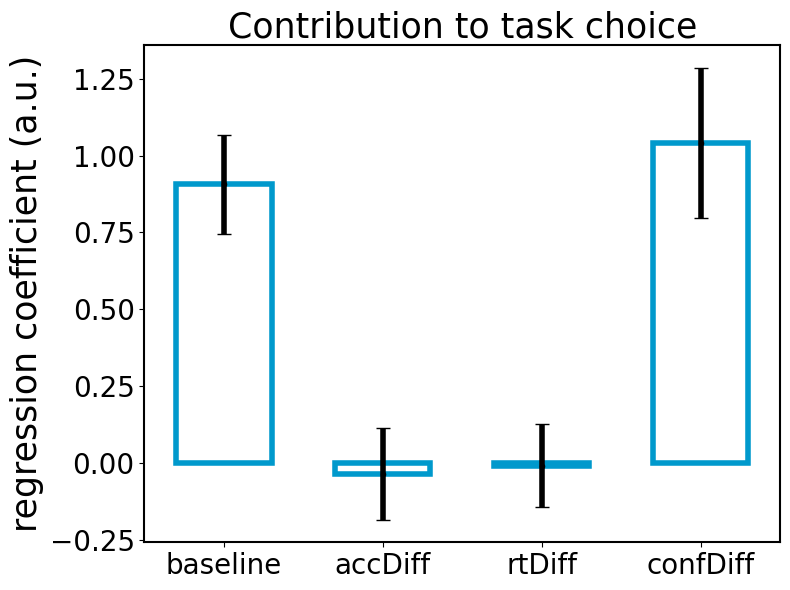

In [59]:
# Figure 5B: Logistic regression — contribution to task choice (pairing 6, no-feedback)
Xacc_z = (X_ser6_all[:, 3] - X_ser6_all[:, 3].mean()) / X_ser6_all[:, 3].std(ddof=1)
Xrt_z  = (X_ser6_all[:, 4] - X_ser6_all[:, 4].mean()) / X_ser6_all[:, 4].std(ddof=1)
Xconf_z = (X_ser6_all[:, 5] - X_ser6_all[:, 5].mean()) / X_ser6_all[:, 5].std(ddof=1)
Y_ch = (X_ser6_all[:, 6] - 1).astype(int)
logit = sm.GLM(Y_ch, sm.add_constant(np.column_stack([Xacc_z, Xrt_z, Xconf_z])),
               family=sm.families.Binomial()).fit(disp=0)
Bser6 = logit.params

color_lr = np.array([0, 153, 204]) / 255
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(np.arange(4), Bser6, facecolor=[1, 1, 1], edgecolor=color_lr, linewidth=4, width=0.6)
ax.errorbar(np.arange(4), Bser6, yerr=logit.bse, fmt='k.', linewidth=4, capsize=5)
ax.set_title('Contribution to task choice', fontsize=25)
ax.set_ylabel('regression coefficient (a.u.)', fontsize=25)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(['baseline', 'accDiff', 'rtDiff', 'confDiff'], fontsize=20)
ax.tick_params(labelsize=20)
ax.set_xlim(-0.5, 3.5)
for sp in ax.spines.values():
    sp.set_linewidth(1.5)
plt.tight_layout()
plt.savefig(project_root / 'outputs' / '02_fig5b_logistic_regression.png',
            dpi=150, bbox_inches='tight')
plt.show()

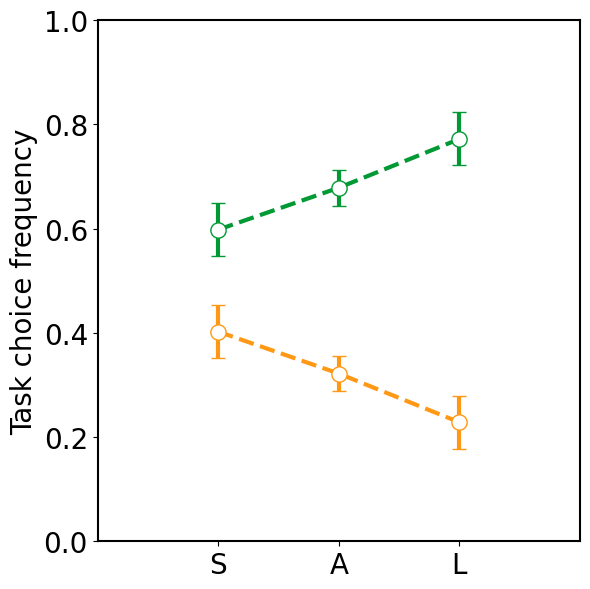

In [60]:
# Figure 5C: Task choice by performance tertile (Low / Mean / High), pairing 6 (NFB70 vs NFB85)
col = 5  # pairing 6, 0-indexed

t1_vals = [T1chperserL[:, col].mean(), T1chperser[:, col].mean(), T1chperserH[:, col].mean()]
t1_sems = [T1chperserL[:, col].std(ddof=1) / np.sqrt(nS),
           T1chperser[:,  col].std(ddof=1) / np.sqrt(nS),
           T1chperserH[:, col].std(ddof=1) / np.sqrt(nS)]
t2_vals = [T2chperserL[:, col].mean(), T2chperser[:, col].mean(), T2chperserH[:, col].mean()]
t2_sems = [T2chperserL[:, col].std(ddof=1) / np.sqrt(nS),
           T2chperser[:,  col].std(ddof=1) / np.sqrt(nS),
           T2chperserH[:, col].std(ddof=1) / np.sqrt(nS)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(x3, t1_vals, yerr=t1_sems, color=colorD, linestyle='--',
            marker='o', markerfacecolor='w', markersize=11, linewidth=3, capsize=5)
ax.errorbar(x3, t2_vals, yerr=t2_sems, color=colorE, linestyle='--',
            marker='o', markerfacecolor='w', markersize=11, linewidth=3, capsize=5)
ax.set_ylabel('Task choice frequency', fontsize=20)
ax.set_xlim(0, 4)
ax.set_ylim(0, 1)
ax.set_xticks(x3)
ax.set_xticklabels(['S', 'A', 'L'], fontsize=20)
ax.tick_params(labelsize=20)
for sp in ax.spines.values():
    sp.set_linewidth(1.5)
plt.tight_layout()
plt.savefig(project_root / 'outputs' / '02_fig5c_task_choice_performance_tertile.png',
            dpi=150, bbox_inches='tight')
plt.show()

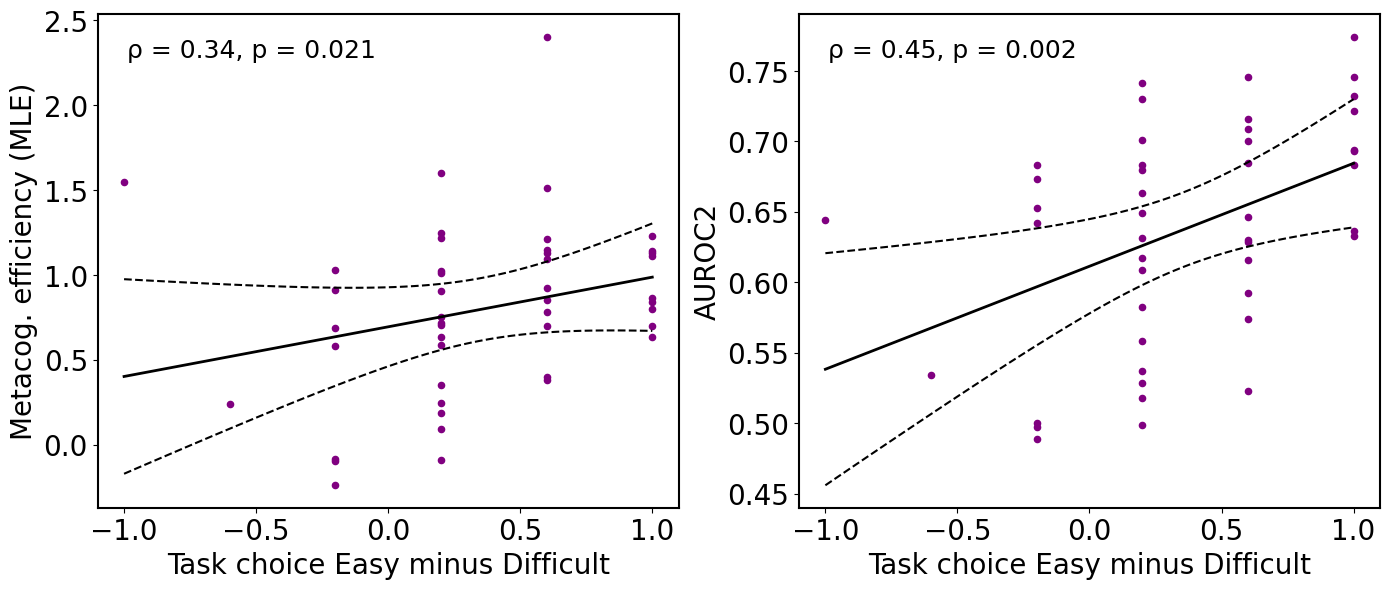

In [ ]:
# Figure 5D: Metacognitive efficiency vs task choice bias
# Replicates regression_line_ci.m using F-distribution confidence band
from scipy.stats import linregress, f as fdist, spearmanr

def regression_ci(x, y, alpha=0.05, n_pts=100):
    slope, intercept, _, _, _ = linregress(x, y)
    N = len(x)
    X = np.linspace(x.min(), x.max(), n_pts + 1)
    Y = intercept + slope * X
    SSR = np.sum((y - intercept - slope * x) ** 2) / (N - 2)
    SSX = np.sum((x - x.mean()) ** 2)
    Yoff = np.sqrt(2 * fdist.ppf(1 - alpha, 2, N - 2) * SSR * (1/N + (X - x.mean())**2 / SSX))
    return X, Y, Y + Yoff, Y - Yoff

delta = T2chperser[:, 5] - T1chperser[:, 5]
Mratio_avg = (mratios[:, 0] + mratios[:, 1]) / 2
AUROC_avg  = (auroc2[:,  0] + auroc2[:,  1]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MLE M-ratio — all subjects, including negative estimates
X_m, Y_m, top_m, bot_m = regression_ci(delta, Mratio_avg)
rho_m, p_rho_m = spearmanr(delta, Mratio_avg)

ax = axes[0]
ax.scatter(delta, Mratio_avg, c='purple', s=20)
ax.plot(X_m, Y_m, 'k', linewidth=2)
ax.plot(X_m, top_m, 'k--', linewidth=1.5)
ax.plot(X_m, bot_m, 'k--', linewidth=1.5)
ax.text(0.05, 0.95, f'ρ = {rho_m:.2f}, p = {p_rho_m:.3f}',
        transform=ax.transAxes, fontsize=18, va='top')
ax.set_ylabel('Metacog. efficiency (MLE)', fontsize=20)
ax.set_xlabel('Task choice Easy minus Difficult', fontsize=20)
ax.tick_params(labelsize=20)
for sp in ax.spines.values():
    sp.set_linewidth(1.5)

# AUROC2
X_a, Y_a, top_a, bot_a = regression_ci(delta, AUROC_avg)
rho_a, p_rho_a = spearmanr(delta, AUROC_avg)

ax = axes[1]
ax.scatter(delta, AUROC_avg, c='purple', s=20)
ax.plot(X_a, Y_a, 'k', linewidth=2)
ax.plot(X_a, top_a, 'k--', linewidth=1.5)
ax.plot(X_a, bot_a, 'k--', linewidth=1.5)
ax.text(0.05, 0.95, f'ρ = {rho_a:.2f}, p = {p_rho_a:.3f}',
        transform=ax.transAxes, fontsize=18, va='top')
ax.set_ylabel('AUROC2', fontsize=20)
ax.set_xlabel('Task choice Easy minus Difficult', fontsize=20)
ax.tick_params(labelsize=20)
for sp in ax.spines.values():
    sp.set_linewidth(1.5)

plt.tight_layout()
plt.savefig(project_root / 'outputs' / '02_fig5ed_metacog_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()
